# DDPM Example Training Notebook

This script walks through the full workflow of training a model

In [16]:
import torch
from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders, NoisyMNIST
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated

from cluster import train_on_cluster, job_status
from cluster import get_save_path,get_losses_path,get_config_path
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Noise scheduler and data

if you want to train on a subset of the data, use get_noisy_loaders_filtered

In [17]:
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02)

train_set, test_set = load_mnist()
train_set_noisy = NoisyMNIST(train_set, scheduler)
test_set_noisy = NoisyMNIST(test_set,  scheduler)

train_loader, test_loader = get_noisy_loaders(train_set, test_set, scheduler, batch_size=32)

## 2. Build a UNet

`channels` sets the feature map depth at each encoder level.
The decoder mirrors this automatically.
`convs_per_level` is how many conv layers per resolution block.

### TO SET

In [18]:
channel0 = 128
cpl = 2 

In [19]:
channels = channel_list(channel0) 
                      # convs per level

#model_path = '/home/scur0036/diffusion-models-project/models/base_C0_128_convs_2wd_1e-6_long.pkl'

unet = UNet(channels,cpl)

print(f"Model: {model_name(channel0, cpl)}")
print(f"Parameters: {sum(p.numel() for p in unet.parameters()):,}")

Model: C0_128_convs_2
Parameters: 7,524,097


## 4. Train

### TO SET

In [20]:
job_name = 'unet_C0_128_convs_2'

### Send training to cluster

In [21]:
# submit
job_id, save_path = train_on_cluster(
    unet,train_set_noisy,test_set_noisy,
    epochs=300,
    batch_size = 32,
    weight_decay=1e-6,
    early_stopping=15,
    job_name=job_name,
    time="02:00:00"
)

Serialized model      → /home/scur0036/diffusion-models-project/models/unet_C0_128_convs_2/init.pt
Serialized train data → /home/scur0036/diffusion-models-project/models/unet_C0_128_convs_2/train_dataset.pt
Serialized test data  → /home/scur0036/diffusion-models-project/models/unet_C0_128_convs_2/test_dataset.pt
Submitted batch job 22737663
Logs:    /home/scur0036/diffusion-models-project/logs/unet_C0_128_convs_2_22737663.out
Trained model will be saved to: /home/scur0036/diffusion-models-project/models/unet_C0_128_convs_2/trained.pkl


## check job status

In [22]:
job_status(job_name)

Job unet_C0_128_convs_2 no longer in queue (finished or failed).


or simply

In [23]:
! squeue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          22737663  gpu_a100 unet_C0_ scur0036 PD       0:00      1 (Resources)


# 5. Loading a trained model

In [10]:
config = torch.load(get_config_path(job_name))
unet   = UNet(**config)
unet.load_state_dict(torch.load(get_save_path(job_name),map_location=device))

# load losses
losses = torch.load(get_losses_path(job_name))
train_losses,test_losses = losses['train'],losses['test']


Plot the loss curves manually (training doesn't do this anymore):

In [11]:
def plot_loss(train_losses,test_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses,  label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Loss curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

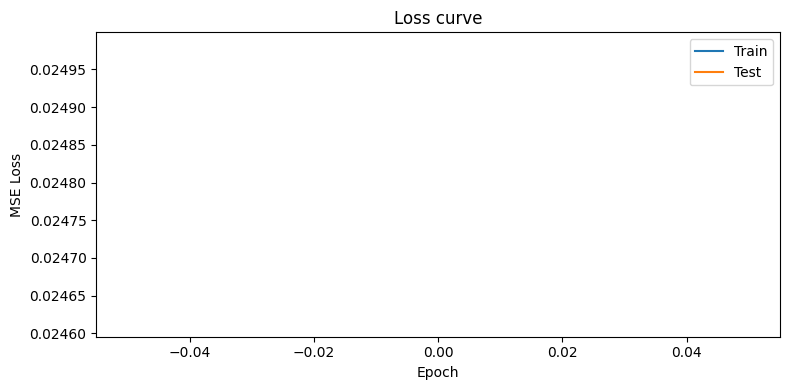

In [12]:
plot_loss(train_losses,test_losses)

## 6. Generate images

In [14]:
x = generate_image(unet, scheduler, stochasticity=1.0, n_images=1)
plot_generated(x, ncol=1)

KeyboardInterrupt: 

### Intermediates

In [ ]:
x_final, intermediates = generate_image(
    unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=True
)

# Plot every 100th step
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
steps_to_show = list(range(0, 1000, 100)) + [999]
for ax, idx in zip(axes, steps_to_show):
    img = intermediates[idx].squeeze()
    if img.min() < 0:
        img = (img + 1) / 2
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.set_title(f't={1000 - idx}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()